# Testeos iniciales: implementaciones 1D

##Modelo 1

Epoch 0 | Total Loss: 8.9066e-01
Epoch 2000 | Total Loss: 1.1137e-02
Epoch 4000 | Total Loss: 2.4241e-04
Epoch 6000 | Total Loss: 1.5601e-05
Epoch 8000 | Total Loss: 4.6927e-06
Epoch 10000 | Total Loss: 2.8760e-06
Epoch 12000 | Total Loss: 7.4202e-06
Epoch 14000 | Total Loss: 1.5572e-06
Epoch 16000 | Total Loss: 2.5941e-06
Epoch 18000 | Total Loss: 2.0597e-06
Epoch 20000 | Total Loss: 2.8366e-05
Epoch 22000 | Total Loss: 5.9665e-07
Epoch 24000 | Total Loss: 4.9209e-07
Epoch 26000 | Total Loss: 4.1918e-07
Epoch 28000 | Total Loss: 3.6612e-07
Epoch 30000 | Total Loss: 5.4114e-07
Epoch 32000 | Total Loss: 3.6678e-07
Epoch 34000 | Total Loss: 2.6489e-07
Epoch 36000 | Total Loss: 9.2588e-07
Epoch 38000 | Total Loss: 2.3076e-07
Epoch 40000 | Total Loss: 2.6603e-07
Epoch 42000 | Total Loss: 1.9899e-07
Epoch 44000 | Total Loss: 1.8892e-07
Epoch 46000 | Total Loss: 2.2926e-07
Epoch 48000 | Total Loss: 2.8841e-07


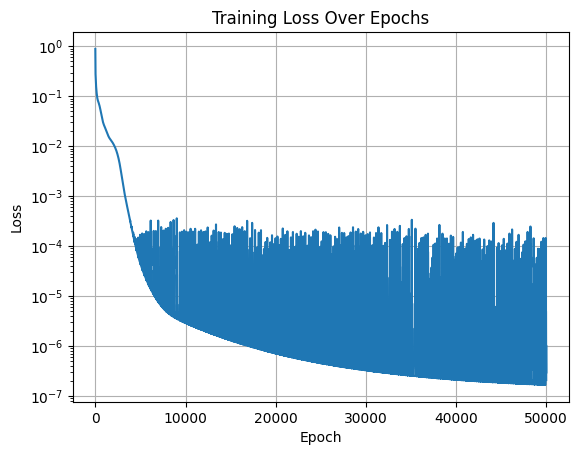

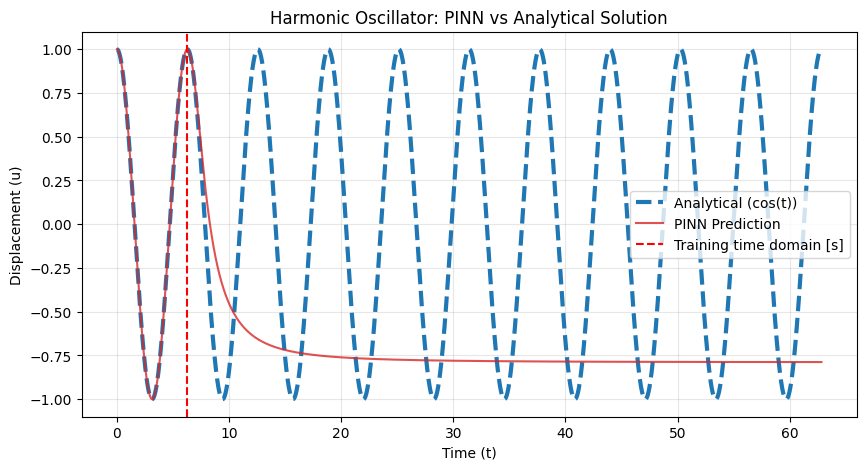

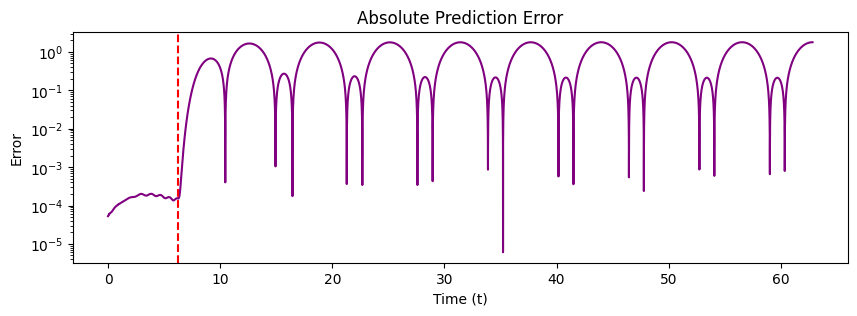

In [21]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class OptimalPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20), nn.Tanh(),  # Activation: Tanh [cite: 303]
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, t):
        return self.net(t)

def Main_model_1(lam1, lam2):

    # sampleo sobol para training domain
    soboleng = torch.quasirandom.SobolEngine(dimension=1)
    training_sample_length = 2*np.pi
    t_sobol = soboleng.draw(500) * (training_sample_length)
    t_physics = t_sobol.to(device).requires_grad_(True)
    # lambda_1, lambda_2 = 1000.0, 1000.0 los chinos
    lambda_1, lambda_2 = 1.0, 1.0
    model = OptimalPINN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # Adam optimizer [cite: 34, 226]
    loss = []

    # High iterations recommended for convergence [cite: 304, 704]
    for epoch in range(50000):
        optimizer.zero_grad()

        # CDB / CI
        t_0 = torch.tensor([[0.0]], device=device, requires_grad=True)
        u_0 = model(t_0)



        loss_u = torch.mean((u_0 - 1.0)**2)

        u_t0 = torch.autograd.grad(u_0, t_0, torch.ones_like(u_0), create_graph=True)[0]
        loss_v = torch.mean(u_t0**2)

        u_phys = model(t_physics)
        u_t = torch.autograd.grad(u_phys, t_physics, torch.ones_like(u_phys), create_graph=True)[0] # u'
        u_tt = torch.autograd.grad(u_t, t_physics, torch.ones_like(u_t), create_graph=True)[0]      # u''
        loss_f = torch.mean((u_tt + u_phys)**2)     # porque se supone que u'' + u = 0  (entonces acá va el operador dif. homogeneizado)

        total_loss = loss_f + (lambda_1 * loss_u) + (lambda_2 * loss_v)

        total_loss.backward()
        optimizer.step()
        loss.append(total_loss.item())
        if epoch % 2000 == 0:
            print(f"Epoch {epoch} | Total Loss: {total_loss.item():.4e}")

    plt.plot(loss)
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.grid()
    plt.show()



    t_test = torch.linspace(0, 20*np.pi, 20000).view(-1, 1).to(device)
    model.eval()
    with torch.no_grad():
        u_pred = model(t_test)

    t_plot = t_test.cpu().numpy()
    u_plot = u_pred.cpu().numpy()
    u_pred_modelo1 = u_pred.cpu().numpy()

    u_true = np.cos(t_plot)     #Sol teórica
    plt.figure(figsize=(10, 5))
    plt.plot(t_plot, u_true, label="Analytical (cos(t))", color="tab:blue", linestyle="dashed", lw=3)
    plt.plot(t_plot, u_plot, label="PINN Prediction", color="tab:red", alpha=0.8)
    plt.axvline(x=training_sample_length, label="Training time domain [s]", color="red", linestyle="--")
    plt.title("Harmonic Oscillator: PINN vs Analytical Solution")
    plt.xlabel("Time (t)")
    plt.ylabel("Displacement (u)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    error = np.abs(u_plot - u_true)

    plt.figure(figsize=(10, 3))
    plt.plot(t_plot, error, color="purple")
    plt.axvline(x=training_sample_length, label="Training time domain [s]", color="red", linestyle="--")
    plt.yscale('log') # Error is often small, so log scale helps
    plt.title("Absolute Prediction Error")
    plt.xlabel("Time (t)")
    plt.ylabel("Error")
    plt.show()

    return u_pred_modelo1, loss

u_pred_modelo1, loss = Main_model_1(1.0, 1.0)

##Modelo 1.1

Epoch 0 | Total Loss: 7.7955e-01
Epoch 2000 | Total Loss: 2.9832e-05
Epoch 4000 | Total Loss: 8.5569e-06
Epoch 6000 | Total Loss: 4.3336e-06
Epoch 8000 | Total Loss: 2.8890e-06
Epoch 10000 | Total Loss: 2.0966e-06
Epoch 12000 | Total Loss: 4.4896e-05
Epoch 14000 | Total Loss: 8.3172e-07
Epoch 16000 | Total Loss: 5.1649e-07
Epoch 18000 | Total Loss: 9.4357e-07


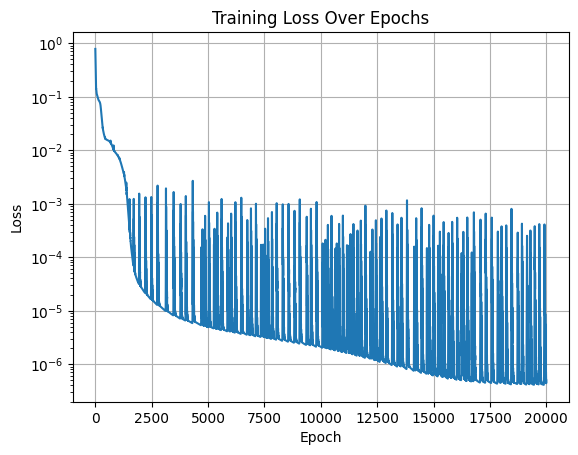

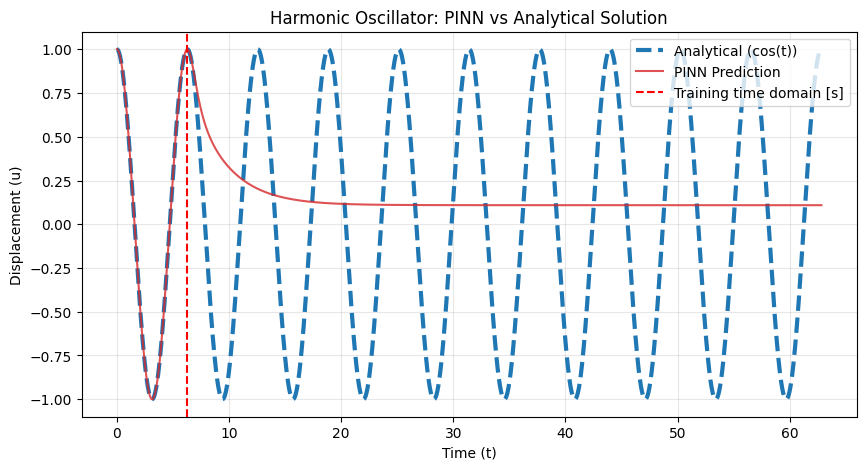

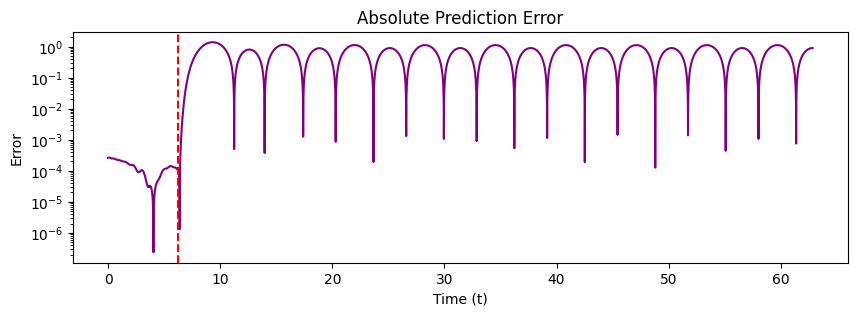

In [22]:
import torch
import torch.nn as nn
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class OptimalPINN(nn.Module):
    def __init__(self):
        super().__init__()
        # 5 hidden layers with 20 neurons each [cite: 707, 762]
        self.net = nn.Sequential(
            nn.Linear(1, 20), nn.Tanh(),  # Activation: Tanh [cite: 303]
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, t):
        return self.net(t)

def Main_model_2(lam1, lam2):
    soboleng = torch.quasirandom.SobolEngine(dimension=1)
    training_sample_length = 2*np.pi
    t_sobol = soboleng.draw(500) * training_sample_length
    t_physics = t_sobol.to(device).requires_grad_(True)
    lambda_1, lambda_2 = 1.0, 1.0
    model = OptimalPINN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # Adam optimizer [cite: 34, 226]
    loss = []

    for epoch in range(20000):
        optimizer.zero_grad()


        t_0 = torch.tensor([[0.0]], device=device, requires_grad=True)
        u_0 = model(t_0)


        # Loss u: Initial Displacement u(0) = 1
        loss_u = torch.mean((u_0 - 1.0)**2)

        # Loss v: Initial Velocity u'(0) = 0
        u_t0 = torch.autograd.grad(u_0, t_0, torch.ones_like(u_0), create_graph=True)[0]
        loss_v = torch.mean(u_t0**2)

        # Loss f: Governing Equation u'' + u = 0
        u_phys = model(t_physics)
        u_t = torch.autograd.grad(u_phys, t_physics, torch.ones_like(u_phys), create_graph=True)[0] # u'
        u_tt = torch.autograd.grad(u_t, t_physics, torch.ones_like(u_t), create_graph=True)[0]      # u''
        loss_f = torch.mean((u_tt + u_phys)**2)     # porque se supone que u'' + u = 0  (entonces acá va el operador dif. homogeneizado)

        # Total Weighted Loss [cite: 206]
        total_loss = loss_f + (lambda_1 * loss_u) + (lambda_2 * loss_v)

        total_loss.backward()
        optimizer.step()
        loss.append(total_loss.item())
        if epoch % 2000 == 0:
            print(f"Epoch {epoch} | Total Loss: {total_loss.item():.4e}")

    plt.plot(loss)
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.grid()
    plt.show()



    # 1. Create a dense time vector for a smooth plot
    t_test = torch.linspace(0, 20*np.pi, 20000).view(-1, 1).to(device)

    # 2. Get predictions
    model.eval()
    with torch.no_grad():
        u_pred = model(t_test)


    t_plot = t_test.cpu().numpy()
    u_plot = u_pred.cpu().numpy()
    u_pred_modelo2 = u_pred.cpu().numpy()
    u_true = np.cos(t_plot)
    plt.figure(figsize=(10, 5))
    plt.plot(t_plot, u_true, label="Analytical (cos(t))", color="tab:blue", linestyle="dashed", lw=3)
    plt.plot(t_plot, u_plot, label="PINN Prediction", color="tab:red", alpha=0.8)
    plt.axvline(x=training_sample_length, label="Training time domain [s]", color="red", linestyle="--")
    plt.title("Harmonic Oscillator: PINN vs Analytical Solution")
    plt.xlabel("Time (t)")
    plt.ylabel("Displacement (u)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    error = np.abs(u_plot - u_true)

    plt.figure(figsize=(10, 3))
    plt.plot(t_plot, error, color="purple")
    plt.axvline(x=training_sample_length, label="Training time domain [s]", color="red", linestyle="--")
    plt.yscale('log')
    plt.title("Absolute Prediction Error")
    plt.xlabel("Time (t)")
    plt.ylabel("Error")
    plt.show()
    return u_pred_modelo2, loss

u_pred_modelo2, loss = Main_model_2(1.0, 1.0)

## Modelo 2

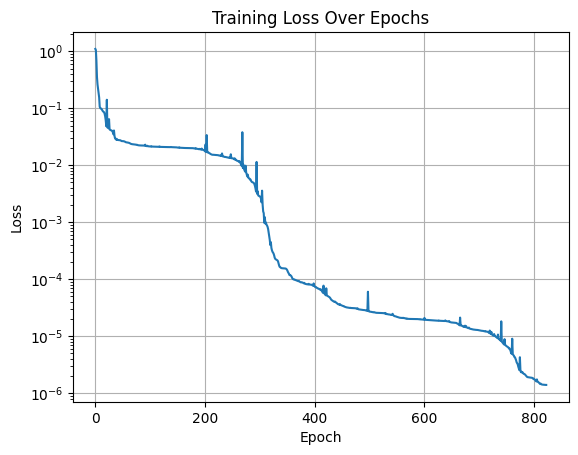

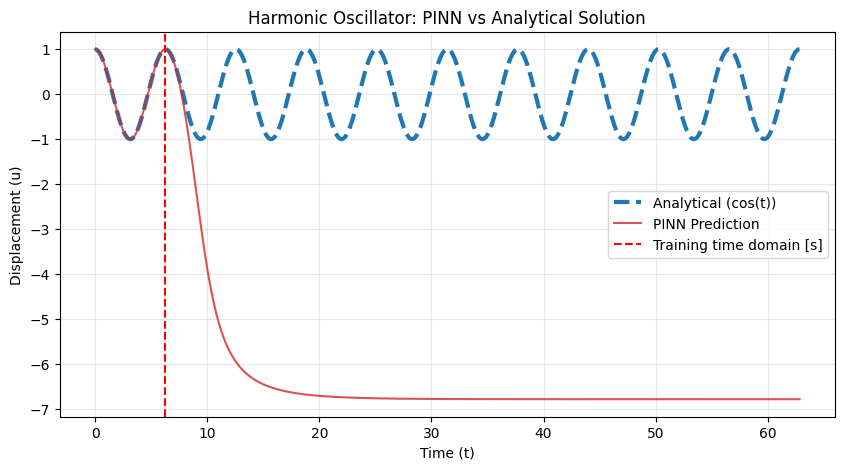

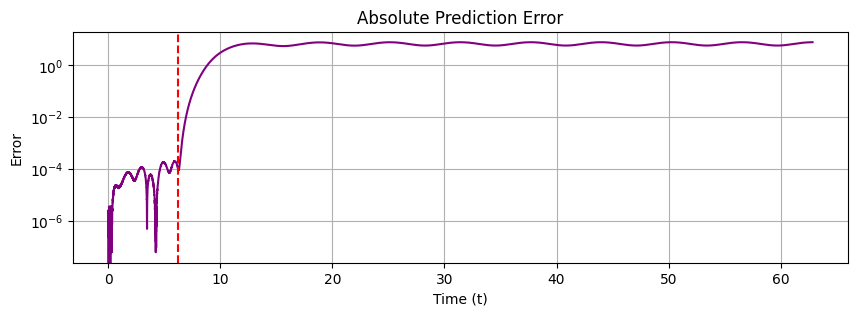

In [23]:
import torch
import torch.nn as nn
import numpy as np

# 1. Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Network Configuration (Based on Study Recommendations)
class OptimalPINN(nn.Module):
    def __init__(self):
        super().__init__()
        # probamos aumentar el tamaño de la red para ver como afecta
        self.net = nn.Sequential(
            nn.Linear(1, 50), nn.Tanh(),  # Activation: Tanh [cite: 303]
            nn.Linear(50, 100), nn.Tanh(),
            nn.Linear(100, 100), nn.Tanh(),
            nn.Linear(100, 100), nn.Tanh(),
            nn.Linear(100, 100), nn.Tanh(),
            nn.Linear(100, 50), nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, t):
        return self.net(t)


def Main_model_3(lam1, lam2):

    soboleng = torch.quasirandom.SobolEngine(dimension=1)
    training_sample_length = 2*np.pi        #Aca definimos el dominio de entrenamiento
    t_sobol = soboleng.draw(500) * (training_sample_length)
    t_physics = t_sobol.to(device).requires_grad_(True)
    # print(t_physics)      #es un array desordenado de tiempo en el intervalo dado
    model = OptimalPINN().to(device)


    # Los chinos decían que funcionaba bien poner estos pesos en ~1k para dejar las CDB "bien fijadas" pero por ahora la verdad no me ha hecho falta
    lambda_1, lambda_2 = 1.0, 1.0

    # Change 2: Use L-BFGS (example setup)
    optimizer = torch.optim.LBFGS(model.parameters(),
                                lr=1,
                                max_iter=50000,
                                history_size=50,
                                tolerance_grad=1e-15,
                                line_search_fn='strong_wolfe')


    loss = []
    epoch=0

    def closure():
        optimizer.zero_grad()
        # Boundary/Initial Points
        t_0 = torch.tensor([[0.0]], device=device, requires_grad=True)
        u_0 = model(t_0)

        # Loss u: CdB cos(0) = 1
        loss_u = torch.mean((u_0 - 1.0)**2)

        # Loss v: u'(0) = -sin(0) = 0
        u_t0 = torch.autograd.grad(u_0, t_0, torch.ones_like(u_0), create_graph=True)[0]
        loss_v = torch.mean(u_t0**2)

        # Loss f: oscilador armonico u'' + u = 0
        u_phys = model(t_physics)
        u_t = torch.autograd.grad(u_phys, t_physics, torch.ones_like(u_phys), create_graph=True)[0]
        u_tt = torch.autograd.grad(u_t, t_physics, torch.ones_like(u_t), create_graph=True)[0]
        loss_f = torch.mean((u_tt + u_phys)**2)  #nos saca el residuo de la ED

        # Total Loss
        total_loss = loss_f + loss_u + loss_v
        total_loss.backward()
        loss.append(total_loss.item())
        # if epoch % 2000 == 0:
        #     print(f"Epoch {epoch} | Total Loss: {total_loss.item():.4e}")
        # epoch+=1
        return total_loss

    optimizer.step(closure)


    plt.plot(loss)
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.grid()
    plt.show()


    #Testeamos la red:
    t_test = torch.linspace(0, 20*np.pi, 20000).view(-1, 1).to(device)
    model.eval()
    with torch.no_grad():
        u_pred = model(t_test)

    t_plot = t_test.cpu().numpy()
    u_plot = u_pred.cpu().numpy()

    u_true = np.cos(t_plot)  #Sol teórica
    u_pred_modelo3 = u_pred.cpu().numpy() #guardamos para plotear despues
    plt.figure(figsize=(10, 5))
    plt.plot(t_plot, u_true, label="Analytical (cos(t))", color="tab:blue", linestyle="dashed", lw=3)
    plt.plot(t_plot, u_plot, label="PINN Prediction", color="tab:red", alpha=0.8)
    plt.axvline(x=training_sample_length, label="Training time domain [s]", color="red", linestyle="--")
    plt.title("Harmonic Oscillator: PINN vs Analytical Solution")
    plt.xlabel("Time (t)")
    plt.ylabel("Displacement (u)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    error = np.abs(u_plot - u_true)

    plt.figure(figsize=(10, 3))
    plt.plot(t_plot, error, color="purple")
    plt.axvline(x=training_sample_length, color="red", linestyle="--")
    plt.yscale('log') # Error is often small, so log scale helps
    plt.title("Absolute Prediction Error")
    plt.xlabel("Time (t)")
    plt.ylabel("Error")
    plt.grid()
    plt.show()
    return(u_pred_modelo3, loss)

u_pred_modelo3, loss = Main_model_3(1.0, 1.0)

##Ploteamos los 3 primeros modelos en conjunto:


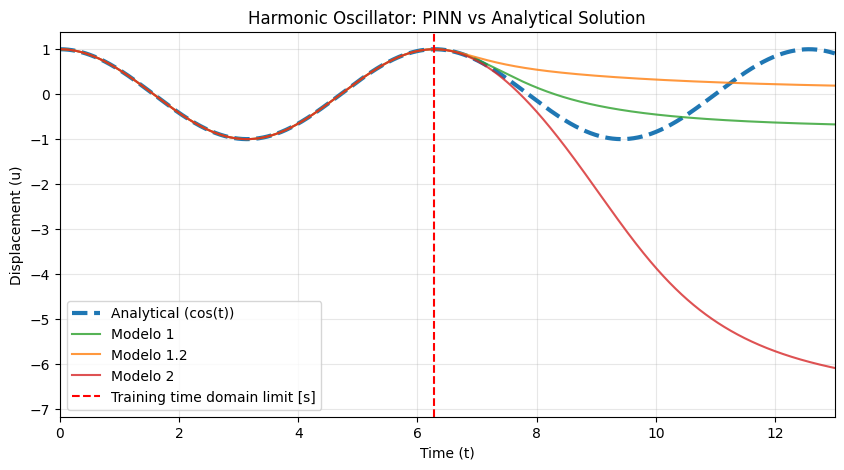

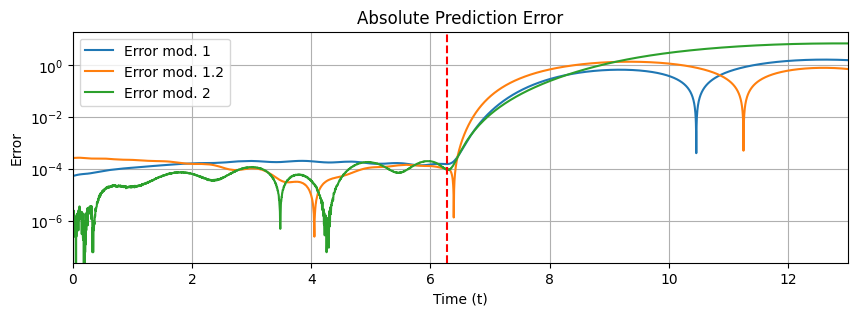

In [24]:

#para lam1, lam2 = 1,1:





u_true = np.cos(t_plot)
plt.figure(figsize=(10, 5))
plt.xlim(0, 13)
plt.plot(t_plot, u_true, label="Analytical (cos(t))", color="tab:blue", linestyle="dashed", lw=3)
plt.plot(t_plot, u_pred_modelo1, label="Modelo 1", color="tab:green", alpha=0.8)
plt.plot(t_plot, u_pred_modelo2, label="Modelo 1.2", color="tab:orange", alpha=0.8)
plt.plot(t_plot, u_pred_modelo3, label="Modelo 2", color="tab:red", alpha=0.8)
plt.axvline(x=training_sample_length, label="Training time domain limit [s]", color="red", linestyle="--")
plt.title("Harmonic Oscillator: PINN vs Analytical Solution")
plt.xlabel("Time (t)")
plt.ylabel("Displacement (u)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

error1 = np.abs(u_pred_modelo1 - u_true)
error2 = np.abs(u_pred_modelo2 - u_true)
error3 = np.abs(u_pred_modelo3 - u_true)

plt.figure(figsize=(10, 3))
plt.xlim(0, 13)
plt.plot(t_plot, error1, label = "Error mod. 1")
plt.plot(t_plot, error2, label = "Error mod. 1.2")
plt.plot(t_plot, error3, label = "Error mod. 2")
plt.legend()
plt.axvline(x=training_sample_length, color="red", linestyle="--")
plt.yscale('log') # Error is often small, so log scale helps
plt.title("Absolute Prediction Error")
plt.xlabel("Time (t)")
plt.ylabel("Error")
plt.grid()
plt.show()

## Modelo 4 RK

Starting simulation...
Step 0/62 completed.
Step 10/62 completed.
Step 20/62 completed.
Step 30/62 completed.
Step 40/62 completed.
Step 50/62 completed.
Step 60/62 completed.


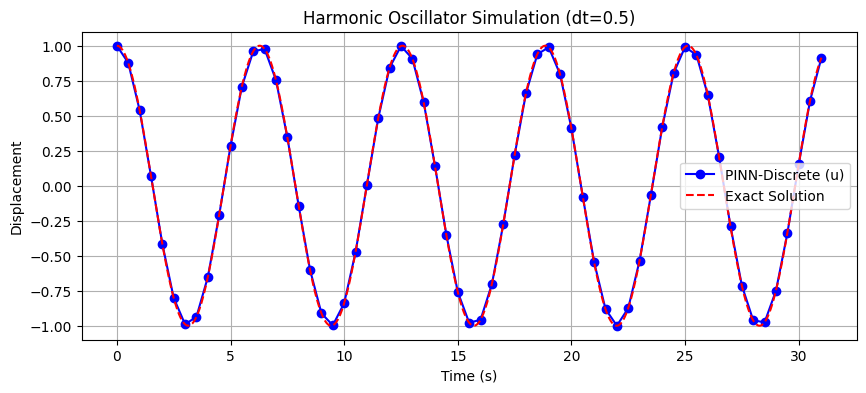

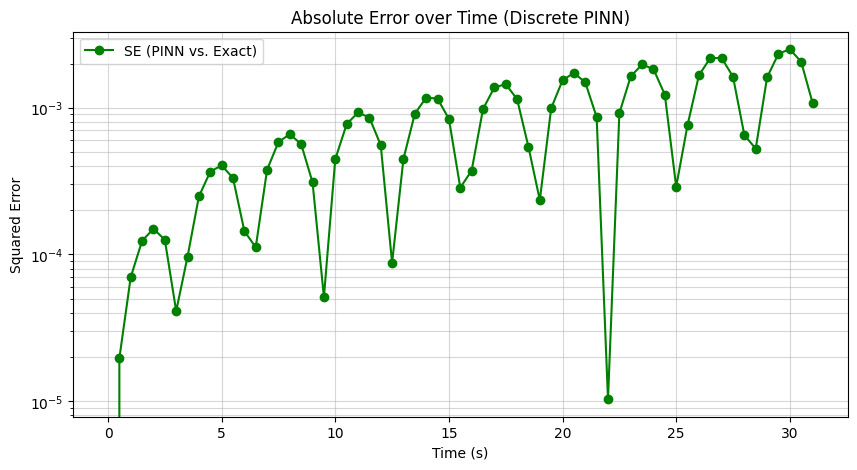

Average RMSE over simulation: 2.8999e-02


In [14]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

A_rk = torch.tensor([[1/4, 1/4 - np.sqrt(3)/6],
                     [1/4 + np.sqrt(3)/6, 1/4]], dtype=torch.float32)
b_rk = torch.tensor([1/2, 1/2], dtype=torch.float32)

class DiscreteStepPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 4)
        )
    def forward(self, x):
        return self.net(x)


def solve_single_step(model, y_n, dt):
    optimizer = torch.optim.LBFGS(model.parameters(), lr=1, max_iter=100, line_search_fn='strong_wolfe')
    placeholder = torch.tensor([[1.0]], requires_grad=True)

    def closure():
        optimizer.zero_grad()
        out = model(placeholder).view(2, 2)
        u_s, v_s = out[:, 0], out[:, 1]

        # Physics: y' = [v, -u]
        f_u, f_v = v_s, -u_s

        # Residuals for Implicit RK
        res_u = u_s - (y_n[0] + dt * torch.matmul(A_rk, f_u))
        res_v = v_s - (y_n[1] + dt * torch.matmul(A_rk, f_v))
        loss = torch.mean(res_u**2 + res_v**2)
        loss.backward()
        return loss

    optimizer.step(closure)

    with torch.no_grad():
        final_out = model(placeholder).view(2, 2)
        f_u_final, f_v_final = final_out[:, 1], -final_out[:, 0]
        u_next = y_n[0] + dt * torch.dot(b_rk, f_u_final)
        v_next = y_n[1] + dt * torch.dot(b_rk, f_v_final)

    return torch.tensor([u_next, v_next])

y_current = torch.tensor([1.0, 0.0],dtype=torch.float32) # CdB /CI: u(0)=1, v(0)=0
solution_domain = int(10*np.pi)        # 5 periodos para resolver
dt = 0.5                             # timestep
total_steps = int(solution_domain / dt)


history = [y_current.numpy()]

model = DiscreteStepPINN()

print("Starting simulation...")
for step in range(total_steps):
    y_current = solve_single_step(model, y_current, dt)
    history.append(y_current.numpy())
    if step % 10 == 0:
        print(f"Step {step}/{total_steps} completed.")

# Ploteos
history = np.array(history)
t_axis = np.linspace(0, total_steps * dt, total_steps + 1)
t_axis_dense = np.linspace(0, total_steps * dt, 1000)
plt.figure(figsize=(10, 4))
plt.plot(t_axis, history[:, 0], 'bo-', label='PINN-Discrete (u)')
plt.plot(t_axis_dense, np.cos(t_axis_dense), 'r--', label='Exact Solution')
plt.title(f"Harmonic Oscillator Simulation (dt={dt})")
plt.xlabel("Time (s)")
plt.ylabel("Displacement")
plt.legend()
plt.grid(True)
plt.show()
u_pinn = history[:, 0]
u_exact = np.cos(t_axis)


mse_values = np.abs((u_pinn - u_exact))
plt.figure(figsize=(10, 5))
plt.semilogy(t_axis, mse_values, 'go-', label='SE (PINN vs. Exact)')

plt.title("Absolute Error over Time (Discrete PINN)")
plt.xlabel("Time (s)")
plt.ylabel("Squared Error")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

print(f"Average RMSE over simulation: {np.sqrt(np.mean(mse_values)):.4e}")